In [ ]:
!pip install matplotlib torch torchvision tqdm numpy ipykernel torch-fidelity

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch_fidelity

import os
import time
import pickle
import zipfile
import numpy as np
import urllib.request
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# 0) Hyperparameters / config
# ------------------------------------------------------------
# Define some params
DATASET_PATH =  '/common/home/users/a/annamalaik.2022/cs-424-group-project-friday/image_image_translation/image_image_translation/'
DEVICE = 'cuda'  # 'cpu' or 'cuda'
OUTPUT_PATH = '/common/home/users/a/annamalaik.2022/cs-424-group-project-friday/work_dirs/Cycle_GAN_01'
CHECKPOINT_SAVE_EVERY = 1
LATENT_DIMS = 100
LR = 0.0002
WORKERS = 4
NETWORK_FEATURES = 64
EPOCH = 200
BATCH_SIZE = 4


# ------------------------------------------------------------
# 1) Define a custom Dataset that returns (cat_img, dog_img)
# ------------------------------------------------------------
# CycleGAN uses *unpaired* image-to-image translation:
# - We do NOT need aligned (apple_i, orange_i) pairs.
# - Instead, during training we sample an apple image from domain A
#   and an orange image from domain B independently.
#
# This dataset class does exactly that by indexing with modulo:
# - apple index cycles through trainA images
# - orange index cycles through trainB images
# and the length is max(len(A), len(B)) so an epoch covers the larger domain.
class Cat2DogDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, train_or_test='train'):
        """
        root_dir:
        /kaggle/input/datasets/kannappan123/cycle-gan-data

        Expected structure:
        root_dir/
            VAE_generation/train
            VAE_generation1/train
        """
        self.dir_A = os.path.join(root_dir, 'VAE_generation', train_or_test)
        self.dir_B = os.path.join(root_dir, 'VAE_generation1', train_or_test)

        self.transform = transform

        self.images_A = sorted(os.listdir(self.dir_A))
        self.images_B = sorted(os.listdir(self.dir_B))

        self.len_A = len(self.images_A)
        self.len_B = len(self.images_B)

        self.length_dataset = max(self.len_A, self.len_B)

    def __len__(self):
        return self.length_dataset

    def __getitem__(self, index):

        img_A = self.images_A[index % self.len_A]
        img_B = self.images_B[index % self.len_B]

        path_A = os.path.join(self.dir_A, img_A)
        path_B = os.path.join(self.dir_B, img_B)

        image_A = Image.open(path_A).convert("RGB")
        image_B = Image.open(path_B).convert("RGB")

        if self.transform:
            image_A = self.transform(image_A)
            image_B = self.transform(image_B)

        return image_A, image_B

# ------------------------------------------------------------
# 2) Preprocessing / augmentation transforms
# ------------------------------------------------------------
# Typical CycleGAN preprocessing for 256x256 images:
# - Resize: make the smaller side (or both sides, depending on PIL) 256
# - RandomCrop: add augmentation by taking random 256x256 patch (helps generalization)
# - RandomHorizontalFlip: add augmentation by randomly flipping left-right (helps generalization)
# - ToTensor: convert to float tensor in [0,1]
# - Normalize: shift to roughly [-1,1] per channel, matching Tanh generator outputs
transform = transforms.Compose([
    transforms.Resize(286),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# ------------------------------------------------------------
# 3) Build train/test datasets
# ------------------------------------------------------------
dataset = Cat2DogDataset(DATASET_PATH, transform=transform, train_or_test='train')
test_dataset = Cat2DogDataset(DATASET_PATH, transform=transform, train_or_test='test')

# ------------------------------------------------------------
# 4) DataLoader: batching + shuffling + I/O performance knobs
# ------------------------------------------------------------
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=WORKERS,
    pin_memory=True,
    drop_last=True
)

# ------------------------------------------------------------
# 6) Output directories
# ------------------------------------------------------------
os.makedirs(os.path.join(OUTPUT_PATH, 'validated_imgs'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'checkpoints'), exist_ok=True)

print("hello")

hello


torch.Size([4, 3, 256, 256])
torch.Size([4, 3, 256, 256])


Text(0.5, 1.0, 'Domain B')

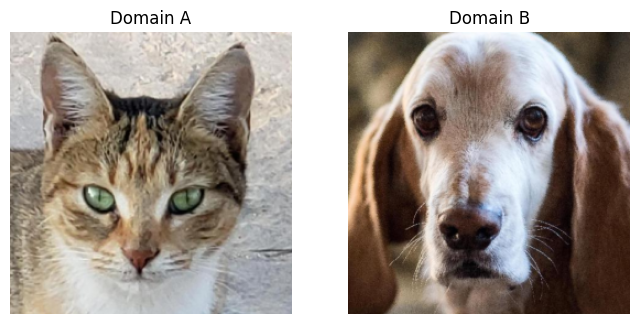

In [40]:
a, b = next(iter(dataloader))

print(a.shape)  # should be [B, 3, 256, 256]
print(b.shape)

def show(img):
    img = img * 0.5 + 0.5  # denormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
show(a[0].cpu())
plt.title("Domain A")

plt.subplot(1,2,2)
show(b[0].cpu())
plt.title("Domain B")

In [ ]:
# -----------------------------
# Residual Block
# -----------------------------
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


# -----------------------------
# Generator
# -----------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # nn.conv2d(in_channels, out_channels, kernel_size, stride, padding)
            nn.Conv2d(3, 64, 7, 1, 3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True),

            *[ResBlock(256) for _ in range(9)],

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 3, 7, 1, 3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# -----------------------------
# Discriminator (PatchGAN)
# -----------------------------
# class Discriminator(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.model = nn.Sequential(
#             # nn.conv2d(in_channels, out_channels, kernel_size, stride, padding)
#             nn.Conv2d(3, 64, 4, 2, 1),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(64, 128, 4, 2, 1),
#             nn.InstanceNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(128, 256, 4, 2, 1),
#             nn.InstanceNorm2d(256),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(256, 512, 4, 1, 1),
#             nn.InstanceNorm2d(512),
#             nn.LeakyReLU(0.2, inplace=True),

#             nn.Conv2d(512, 1, 4, 1, 1)
#         )

#     def forward(self, x):
#         return self.model(x)

from torch.nn.utils import spectral_norm
# We will use spectral normalization in the discriminator to stabilize training, 
# as recommended in the CycleGAN paper and subsequent research.
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Sequential(
                spectral_norm(nn.Conv2d(3, 64, 4, 2, 1)),
                nn.LeakyReLU(0.2, inplace=True)
            ),
            nn.Sequential(
                spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
                nn.InstanceNorm2d(128),
                nn.LeakyReLU(0.2, inplace=True)
            ),
            nn.Sequential(
                spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)),
                nn.InstanceNorm2d(256),
                nn.LeakyReLU(0.2, inplace=True)
            ),
            nn.Sequential(
                spectral_norm(nn.Conv2d(256, 512, 4, 1, 1)),
                nn.InstanceNorm2d(512),
                nn.LeakyReLU(0.2, inplace=True)
            ),
            spectral_norm(nn.Conv2d(512, 1, 4, 1, 1))
        ])

    def forward(self, x, return_features=False):
        feats = []
        for layer in self.layers[:-1]:
            x = layer(x)
            feats.append(x)
        out = self.layers[-1](x)

        if return_features:
            return out, feats
        return out
print("Running Definitions cell for Discriminator - no output expected")

In [ ]:
import random
'''
The buffer stores up to 50 previously generated fake images.

When a new fake batch comes in:

If buffer not full → store and return current fake
If full:
    50% chance → return old fake
    50% chance → return current fake
    replace some stored samples

This "replay" of old fakes helps stabilize discriminator training by preventing it from 
overfitting to the latest generator outputs, which can be highly correlated and 
lead to oscillations. Reduces temporal overfitting to recent generator outputs,
encourages more robust discriminator learning.

A stabilizing technique from the original CycleGAN paper, which found that using a 
history of generated images to train the discriminator (instead of only the latest ones) helps 
prevent the discriminator from overfitting to recent generator outputs, which can lead to oscillations and instability in training.
'''
class ReplayBuffer:
    def __init__(self, max_size=50):
        self.data = []
        self.max_size = max_size

    def push_and_pop(self, batch):
        result = []
        for img in batch:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                result.append(img)
            else:
                if random.random() > 0.5:
                    idx = random.randint(0, self.max_size - 1)
                    result.append(self.data[idx])
                    self.data[idx] = img
                else:
                    result.append(img)
        return torch.cat(result)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

dog_G = Generator().to(DEVICE)   # cat → dog
cat_G = Generator().to(DEVICE)   # dog → cat

dog_D = Discriminator().to(DEVICE)  # judges dogs
cat_D = Discriminator().to(DEVICE)  # judges cats

'''
In CycleGAN, we use the following losses:
1) Adversarial loss: encourages generators to produce realistic images that fool the discriminators.
2) Cycle consistency loss: ensures that if we translate from A to B and back to A, 
   we get back the original image (and similarly for B to A to B).
3) Identity loss: Encourages generators to produce images that are similar to the 
   input image when translated to the same domain.
   
'''
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

def feature_matching_loss(fake, real, D):
    _, fake_feats = D(fake, return_features=True)
    _, real_feats = D(real, return_features=True)

    loss = 0
    for f_fake, f_real in zip(fake_feats, real_feats):
        loss += F.l1_loss(f_fake, f_real.detach())

    return loss

optimizer_G = torch.optim.Adam(
    list(dog_G.parameters()) + list(cat_G.parameters()),
    lr=0.0002, betas=(0.5, 0.999)
)

optimizer_dog_D = torch.optim.Adam(dog_D.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_cat_D = torch.optim.Adam(cat_D.parameters(), lr=0.0002, betas=(0.5, 0.999))

decay_start_epoch = 100

def lambda_rule(epoch):
    return 1.0 - max(0, epoch - decay_start_epoch) / (EPOCH - decay_start_epoch)

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_rule)
lr_scheduler_dog_D = torch.optim.lr_scheduler.LambdaLR(optimizer_dog_D, lr_lambda=lambda_rule)
lr_scheduler_cat_D = torch.optim.lr_scheduler.LambdaLR(optimizer_cat_D, lr_lambda=lambda_rule)

fake_cat_buffer = ReplayBuffer()
fake_dog_buffer = ReplayBuffer()

lambda_cycle = 10

print(DEVICE)

cuda
cuda


In [ ]:

chk_pt_path = "/common/home/users/a/annamalaik.2022/cs-424-group-project-friday/work_dirs/Cycle_GAN_01/checkpoints/ckpt_14.pth"
if os.path.exists(chk_pt_path):
    ckpt = torch.load("/common/home/users/a/annamalaik.2022/cs-424-group-project-friday/work_dirs/Cycle_GAN_01/checkpoints/ckpt_14.pth", map_location=DEVICE)

    dog_G.load_state_dict(ckpt['dog_G'])
    cat_G.load_state_dict(ckpt['cat_G'])
    dog_D.load_state_dict(ckpt['dog_D'])
    cat_D.load_state_dict(ckpt['cat_D'])
    
    optimizer_G.load_state_dict(ckpt['optimizer_G'])
    optimizer_dog_D.load_state_dict(ckpt['optimizer_dog_D'])
    optimizer_cat_D.load_state_dict(ckpt['optimizer_cat_D'])
    
    lr_scheduler_G.load_state_dict(ckpt['lr_scheduler_G'])
    lr_scheduler_dog_D.load_state_dict(ckpt['lr_scheduler_dog_D'])
    lr_scheduler_cat_D.load_state_dict(ckpt['lr_scheduler_cat_D'])
    
    start_epoch = ckpt['epoch'] + 1
else:
    start_epoch = 0
print(start_epoch)

0


In [ ]:
# Training Loop
print("Starting training loop!!!!!!!!")
for epoch in range(start_epoch, EPOCH):
    lambda_id = 5 * max(0.2, (1 - epoch / EPOCH))  # linearly decay identity loss weight to 0 over training
    for i, (real_cat, real_dog) in enumerate(dataloader):
        real_cat = real_cat.to(DEVICE)
        real_dog = real_dog.to(DEVICE)

        # -------------------------
        # Train Generators
        # -------------------------
        optimizer_G.zero_grad()

        fake_dog = dog_G(real_cat)
        fake_cat = cat_G(real_dog)

        # GAN loss
        pred_fake_dog = dog_D(fake_dog)
        # In the original CycleGAN paper, they use MSELoss for the GAN loss, 
        # which corresponds to LSGAN. 
        # This is the generator loss trying to fool the discriminator, 
        # so we want the labels to be "real" (1s)
        loss_GAN_dog = criterion_GAN(pred_fake_dog, torch.ones_like(pred_fake_dog))

        pred_fake_cat = cat_D(fake_cat)
        loss_GAN_cat = criterion_GAN(pred_fake_cat, torch.ones_like(pred_fake_cat))

        '''
            1.L1 loss is used for both cycle consistency and identity losses because 
            it encourages pixel-wise similarity, which is important for these objectives. 
            L1 loss tends to produce sharper images compared to L2.
        '''
        # Cycle loss
        rec_cat = cat_G(fake_dog)
        rec_dog = dog_G(fake_cat)

        loss_cycle_cat = criterion_cycle(rec_cat, real_cat)
        loss_cycle_dog = criterion_cycle(rec_dog, real_dog)

        # Identity loss
        id_cat = cat_G(real_cat)
        id_dog = dog_G(real_dog)

        loss_id_cat = criterion_identity(id_cat, real_cat)
        loss_id_dog = criterion_identity(id_dog, real_dog)

        # loss_G = (
        #     loss_GAN_dog + loss_GAN_cat
        #     + lambda_cycle * (loss_cycle_cat + loss_cycle_dog)
        #     + lambda_id * (loss_id_cat + loss_id_dog)
        # )
        # perceptual loss
        lambda_feat = 5.0

        loss_feat_dog = feature_matching_loss(fake_dog, real_dog, dog_D)
        loss_feat_cat = feature_matching_loss(fake_cat, real_cat, cat_D)
        
        loss_G = (
            loss_GAN_dog + loss_GAN_cat
            + lambda_cycle * (loss_cycle_cat + loss_cycle_dog)
            + lambda_id * (loss_id_cat + loss_id_dog)
            + lambda_feat * (loss_feat_dog + loss_feat_cat)
        )

        loss_G.backward()
        optimizer_G.step()

        # -------------------------
        # Train dog_D
        # -------------------------

        # Reset gradients for dog_D
        optimizer_dog_D.zero_grad()

        # Real loss
        pred_real_dog = dog_D(real_dog)
        loss_real_dog = criterion_GAN(pred_real_dog, torch.ones_like(pred_real_dog))
        
        ''' Fake loss (with buffer)
            1.The buffer stores previously generated fake images and 
            occasionally replaces them with new ones.

            2.Fake_dog.detach() is used to avoid backpropagating through the generator 
            when updating the discriminator.
        '''
        fake_dog_buffered = fake_dog_buffer.push_and_pop(fake_dog.detach())
        pred_fake_dog = dog_D(fake_dog_buffered)
        loss_fake_dog = criterion_GAN(pred_fake_dog, torch.zeros_like(pred_fake_dog))
        
        # Total COMBINED loss
        loss_dog_D = (loss_real_dog + loss_fake_dog) * 0.5
        loss_dog_D.backward()
        optimizer_dog_D.step()

        # -------------------------
        # Train cat_D
        # -------------------------
        optimizer_cat_D.zero_grad()

        # Real loss
        pred_real_cat = cat_D(real_cat)
        loss_real_cat = criterion_GAN(pred_real_cat, torch.ones_like(pred_real_cat))
        
        # Fake loss (with buffer)
        fake_cat_buffered = fake_cat_buffer.push_and_pop(fake_cat.detach())
        pred_fake_cat = cat_D(fake_cat_buffered)
        loss_fake_cat = criterion_GAN(pred_fake_cat, torch.zeros_like(pred_fake_cat))
        
        # Total loss
        loss_cat_D = (loss_real_cat + loss_fake_cat) * 0.5
        loss_cat_D.backward()
        optimizer_cat_D.step()
        
    # -------------------------
    # End of epoch logging
    # -------------------------
    print(f"Epoch [{epoch+1}/{EPOCH}] | G: {loss_G.item():.4f} | D_dog: {loss_dog_D.item():.4f} | D_cat: {loss_cat_D.item():.4f}")

    lr_scheduler_G.step()
    lr_scheduler_dog_D.step()
    lr_scheduler_cat_D.step()

    # -------------------------
    # Optional: Save sample images every 10 epochs
    # -------------------------
    if epoch % 5 == 0:
        with torch.no_grad():
            sample_cat = real_cat[:2]
            sample_dog = real_dog[:2]
    
            fake_dog_vis = dog_G(sample_cat)
            fake_cat_vis = cat_G(sample_dog)
    
            from torchvision.utils import save_image
            save_image((fake_dog_vis * 0.5 + 0.5), f"{OUTPUT_PATH}/epoch_{epoch}_dog.png")
            save_image((fake_cat_vis * 0.5 + 0.5), f"{OUTPUT_PATH}/epoch_{epoch}_cat.png")

    if (epoch + 1) % CHECKPOINT_SAVE_EVERY == 0:
        torch.save({
            'dog_G': dog_G.state_dict(),
            'cat_G': cat_G.state_dict(),
            'dog_D': dog_D.state_dict(),
            'cat_D': cat_D.state_dict(),
            'optimizer_G': optimizer_G.state_dict(),
            'optimizer_dog_D': optimizer_dog_D.state_dict(),
            'optimizer_cat_D': optimizer_cat_D.state_dict(),
            'lr_scheduler_G': lr_scheduler_G.state_dict(),
            'lr_scheduler_dog_D': lr_scheduler_dog_D.state_dict(),
            'lr_scheduler_cat_D': lr_scheduler_cat_D.state_dict(),
            'epoch': epoch
        }, os.path.join(OUTPUT_PATH, 'checkpoints', f'ckpt_{epoch+1}.pth'))
        

Starting training loop!!!!!!!!


In [ ]:
"""
Step 8. Generate Images
"""
data_dir = DATASET_PATH
PATH_TO_CHECKPOINT = "./work_dirs/Cycle_GAN_01/checkpoints/ckpt_200.pth"

batch_size = BATCH_SIZE
transforms_ = transform
# -------------------------
# Load trained models
# -------------------------
checkpoint = torch.load(PATH_TO_CHECKPOINT, map_location=DEVICE)

dog_G.load_state_dict(checkpoint['dog_G'])
cat_G.load_state_dict(checkpoint['cat_G'])

dog_G.eval()
cat_G.eval()

# -------------------------
# Map to baseline variables
# -------------------------
G_AB = dog_G   # A (cat) → B (dog)
G_BA = cat_G   # B (dog) → A (cat)

# -------------------------
# Tensor type
# -------------------------
Tensor = torch.cuda.FloatTensor if DEVICE == "cuda" else torch.FloatTensor


# ============================================================
# Translation 1: A Image --> B Image
# ============================================================

test_dir = os.path.join(data_dir, 'VAE_generation/test')  # modification forbidden
files = [os.path.join(test_dir, name) for name in os.listdir(test_dir)]

save_dir = '/kaggle/working/generated_B_images'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

to_image = transforms.ToPILImage()

G_AB.eval()
for i in range(0, len(files), batch_size):

    imgs = []
    for j in range(i, min(len(files), i+batch_size)):
        img = Image.open(files[j])
        img = transforms_(img)
        imgs.append(img)

    imgs = torch.stack(imgs, 0).type(Tensor)

    # Generate
    fake_imgs = G_AB(imgs).detach().cpu()

    # Save images
    for j in range(fake_imgs.size(0)):
        img = fake_imgs[j].squeeze().permute(1, 2, 0)
        img_arr = img.numpy()

        img_arr = (img_arr - np.min(img_arr)) * 255 / (np.max(img_arr) - np.min(img_arr))
        img_arr = img_arr.astype(np.uint8)

        img = to_image(img_arr)
        _, name = os.path.split(files[i+j])
        img.save(os.path.join(save_dir, name))


# -------------------------
# Compute metrics
# -------------------------
gt_dir = os.path.join(data_dir, 'VAE_generation1/test')

metrics = torch_fidelity.calculate_metrics(
    input1=save_dir,
    input2=gt_dir,
    cuda=True,
    fid=True,
    isc=True
)

fid_score = metrics["frechet_inception_distance"]
is_score = metrics["inception_score_mean"]

if is_score > 0:
    s_value_1 = np.sqrt(fid_score / is_score)
    print("Geometric Mean Score:", s_value_1)
else:
    print("IS is 0, GMS cannot be computed!")


# ============================================================
# Translation 2: B Image --> A Image
# ============================================================

test_dir = os.path.join(data_dir, 'VAE_generation1/test')  # modification forbidden
files = [os.path.join(test_dir, name) for name in os.listdir(test_dir)]

save_dir = '/kaggle/working/generated_A_images'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

G_BA.eval()
for i in range(0, len(files), batch_size):

    imgs = []
    for j in range(i, min(len(files), i+batch_size)):
        img = Image.open(files[j])
        img = transforms_(img)
        imgs.append(img)

    imgs = torch.stack(imgs, 0).type(Tensor)

    # Generate
    fake_imgs = G_BA(imgs).detach().cpu()

    # Save images
    for j in range(fake_imgs.size(0)):
        img = fake_imgs[j].squeeze().permute(1, 2, 0)
        img_arr = img.numpy()

        img_arr = (img_arr - np.min(img_arr)) * 255 / (np.max(img_arr) - np.min(img_arr))
        img_arr = img_arr.astype(np.uint8)

        img = to_image(img_arr)
        _, name = os.path.split(files[i+j])
        img.save(os.path.join(save_dir, name))


# -------------------------
# Compute metrics
# -------------------------
gt_dir = os.path.join(data_dir, 'VAE_generation/test')

metrics = torch_fidelity.calculate_metrics(
    input1=save_dir,
    input2=gt_dir,
    cuda=True,
    fid=True,
    isc=True
)

fid_score = metrics["frechet_inception_distance"]
is_score = metrics["inception_score_mean"]

if is_score > 0:
    s_value_2 = np.sqrt(fid_score / is_score)
    print("Geometric Mean Score:", s_value_2)
else:
    print("IS is 0, GMS cannot be computed!")


# ============================================================
# Final Score + CSV
# ============================================================

s_value = np.round((s_value_1 + s_value_2) / 2, 5)

df = pd.DataFrame({'id': [1], 'label': [s_value]})
csv_path = "Userid.csv"
df.to_csv(csv_path, index=False)

print(f"CSV saved to {csv_path}")